In [11]:
# initialization
import numpy as np
# importing Qiskit
from qiskit import ClassicalRegister, QuantumRegister, QuantumCircuit, transpile
from qiskit_aer import StatevectorSimulator, Aer
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
import math as math
import Utilities as util

# import basic plot tools
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

1.0 |100> 
0.35355 |000> 0.25+0.25j |001> 0.25+0.25j |010> 0.35355j |011> -0.35355 |100> -0.25-0.25j |101> -0.25-0.25j |110> -0.35355j |111> 


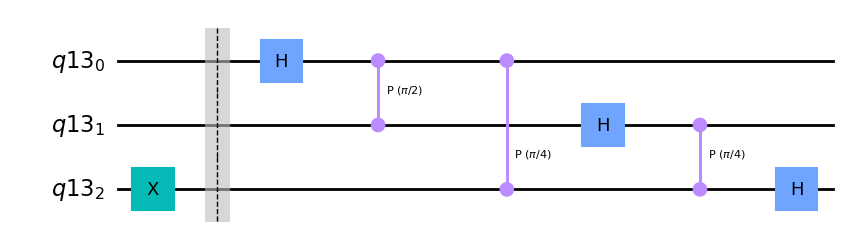

In [12]:
# QFT for 3 qubits

qreg = QuantumRegister(3)
qc = QuantumCircuit(qreg)

qc.x(qreg[2])

util.Wavefunction(qc)

qc.barrier()

# qyubit 0 set up
qc.h(qreg[0])
qc.cp(math.pi/2, qreg[1], qreg[0])
qc.cp(math.pi/4, qreg[2], qreg[0])

# qubit 1 set up
qc.h(qreg[1])
qc.cp(math.pi/4, qreg[2], qreg[1])

# qubit 2 set up
qc.h(qreg[2])

util.Wavefunction(qc)

qc.draw('mpl', style='clifford')



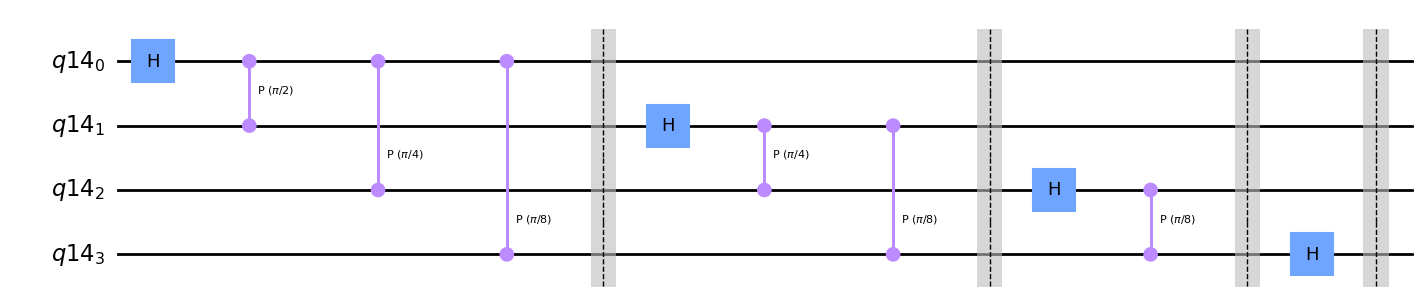

In [13]:
# now implement a generic QFT method for n qubits

def QFT(num_qubits):
    qreg = QuantumRegister(num_qubits)
    qc = QuantumCircuit(qreg)

    for i in range(num_qubits):
        qc.h(qreg[i])
        for j in range(i+1, num_qubits):
            qc.cp(2*math.pi/2**(j+1), qreg[j], qreg[i])
        qc.barrier()

    return qc

QFT(4).draw('mpl', style='clifford')


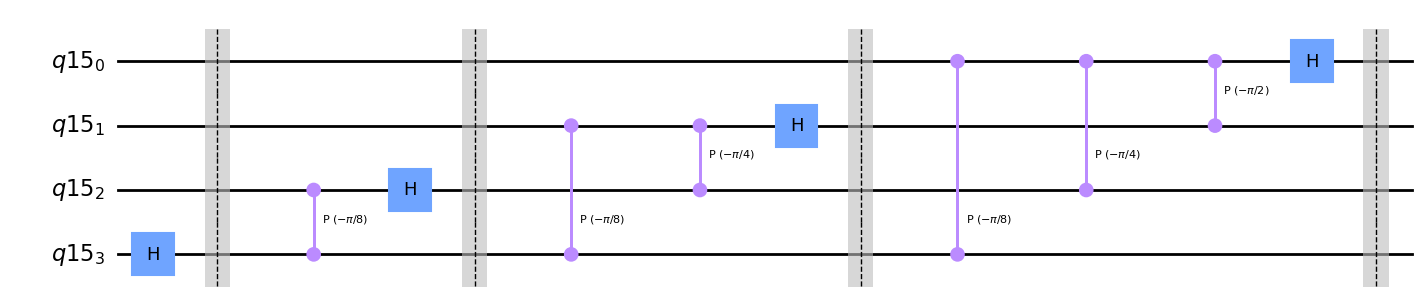

In [14]:
def QFT_dag(num_qubits):
    qreg = QuantumRegister(num_qubits)
    qc = QuantumCircuit(qreg)

    for i in range(num_qubits-1, -1, -1):
        for j in range(num_qubits-1, i, -1):
            qc.cp(-2*math.pi/2**(j+1), qreg[j], qreg[i])
        qc.h(qreg[i])
        qc.barrier()

    return qc

QFT_dag(4).draw('mpl', style='clifford')


Wave function starts with bottom qubit, before QFT: 
1.0 |10000> 
Wave function starts with bottom qubit: 
0.17678 |00000> 0.17338+0.03449j |00001> 0.17338+0.03449j |00010> 0.16332+0.06765j |00011> 0.17338+0.03449j |00100> 0.16332+0.06765j |00101> 0.16332+0.06765j |00110> 0.14698+0.09821j |00111> 0.17338+0.03449j |01000> 0.16332+0.06765j |01001> 0.16332+0.06765j |01010> 0.14698+0.09821j |01011> 0.16332+0.06765j |01100> 0.14698+0.09821j |01101> 0.14698+0.09821j |01110> 0.125+0.125j |01111> -0.17678 |10000> -0.17338-0.03449j |10001> -0.17338-0.03449j |10010> -0.16332-0.06765j |10011> -0.17338-0.03449j |10100> -0.16332-0.06765j |10101> -0.16332-0.06765j |10110> -0.14698-0.09821j |10111> -0.17338-0.03449j |11000> -0.16332-0.06765j |11001> -0.16332-0.06765j |11010> -0.14698-0.09821j |11011> -0.16332-0.06765j |11100> -0.14698-0.09821j |11101> -0.14698-0.09821j |11110> -0.125-0.125j |11111> 
Wave function starts with bottom qubit, after QFT and inverse QFT: 
1.0 |10000> 


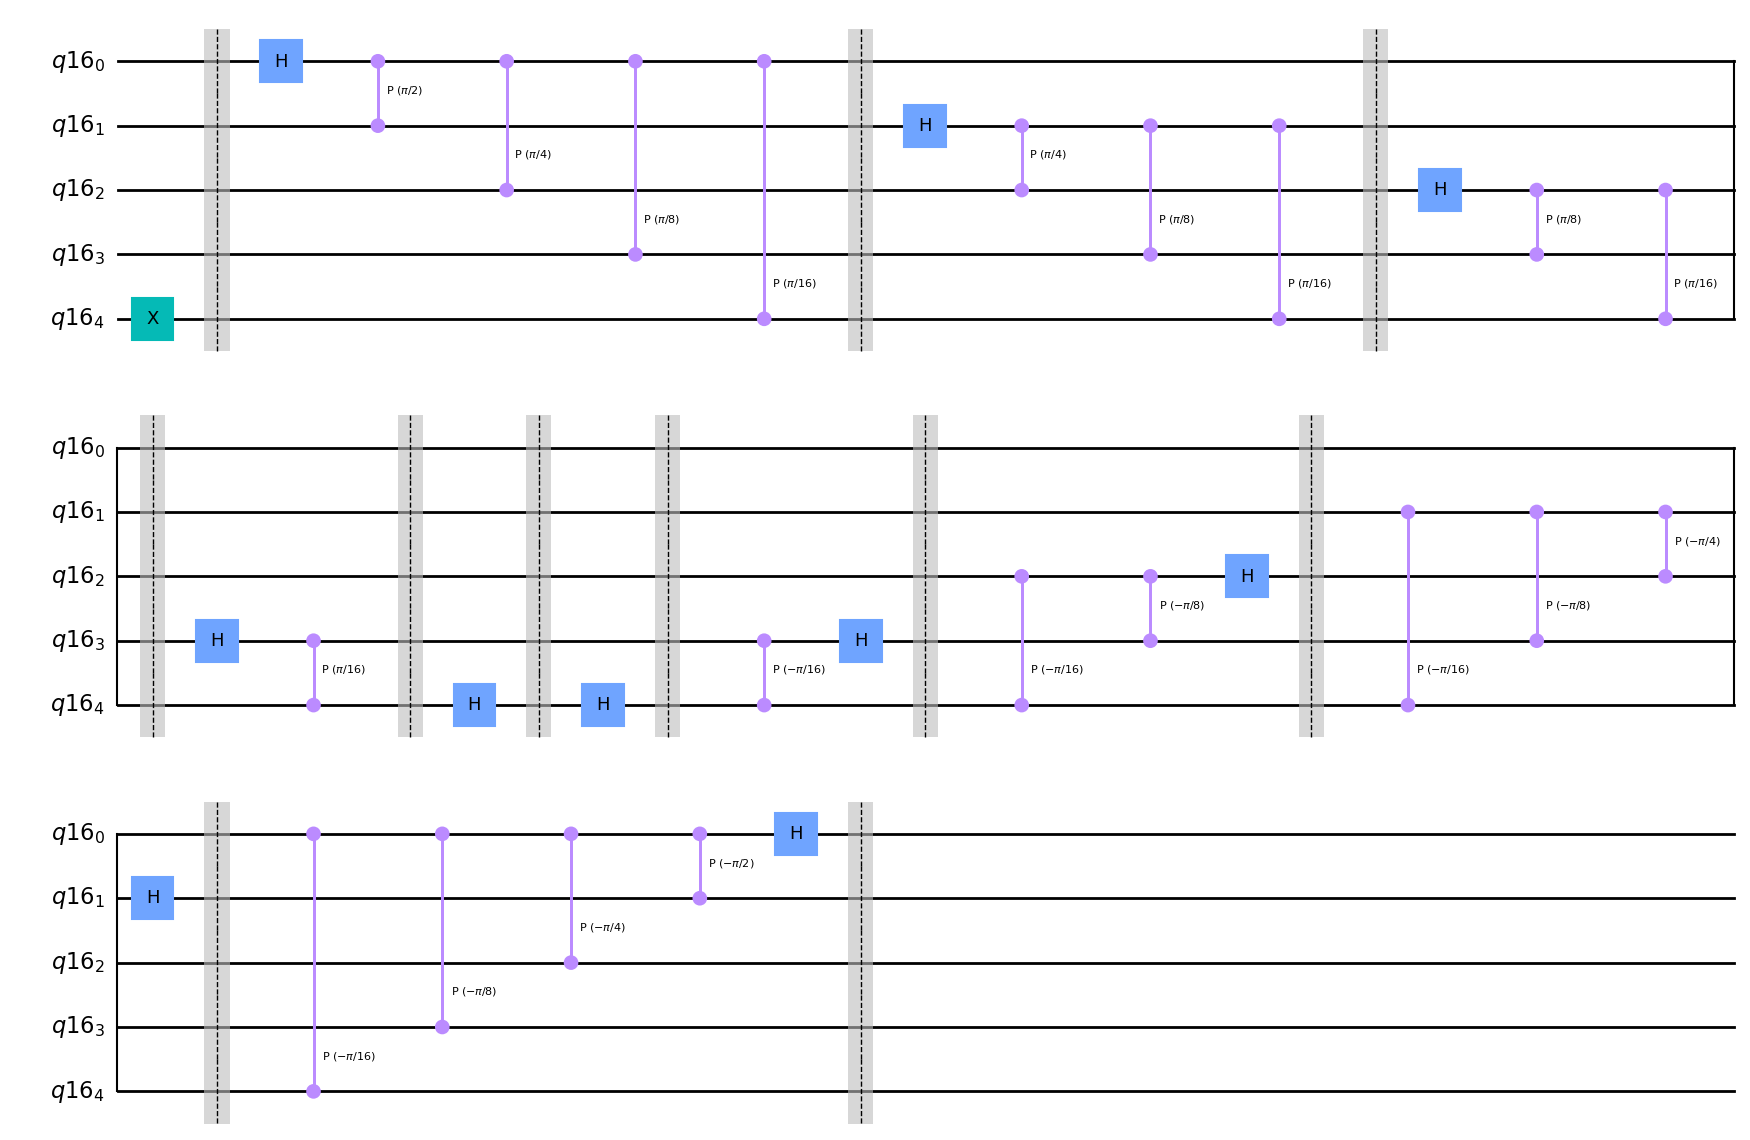

In [15]:
num_qubits = 5

qreg = QuantumRegister(num_qubits)
qc = QuantumCircuit(qreg)

qc.x(qreg[num_qubits-1])
qc.barrier()
print("Wave function starts with bottom qubit, before QFT: ")
util.Wavefunction(qc)

qc.compose(QFT(num_qubits), inplace=True)
print("Wave function starts with bottom qubit: ")
util.Wavefunction(qc)

qc.compose(QFT_dag(num_qubits), inplace=True)
print("Wave function starts with bottom qubit, after QFT and inverse QFT: ")
util.Wavefunction(qc)
qc.draw('mpl', style='clifford')

